## Pain ratings variability analysis continued

### The file contains:
- **Statistical tests for significance of variability across groups**
  - ART anova
  - post hoc tests mann whitney 
  - post hoc tests permutation and boostrap
  - post hoc tests performed exluding of the 'chronic' group

In [26]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.stats import rankdata
from scipy.stats import levene, shapiro
from statsmodels.stats.anova import anova_lm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
ratings = pd.read_csv("Results/Intermediate_Files/ratings_significance_analysis.csv")
ratings

,Unnamed: 0,subject,visit,run,group,average_pain,ratings_std,ratings_variance,CV,IQR
0,0,sub-001,visit1,run_01,SBPr,38.132750,10.865937,118.068579,28.495025,16.520000
1,1,sub-001,visit1,run_02,SBPr,22.862667,3.417062,11.676311,14.946033,4.445000
2,2,sub-001,visit2,run_01,SBPr,22.580528,3.591605,12.899624,15.905760,6.591883
3,3,sub-001,visit2,run_02,SBPr,24.926812,1.386201,1.921552,5.561082,2.422229
4,4,sub-001,visit4,run_01,SBPr,9.183889,1.583665,2.507993,17.243943,1.934680
...,...,...,...,...,...,...,...,...,...,...
558,606,sub-120,visit4,run_01,chronic,65.114483,2.784170,7.751600,4.275807,4.500614
559,607,sub-121,visit1,run_01,chronic,30.701192,3.465422,12.009153,11.287583,4.968554
560,608,sub-121,visit1,run_02,chronic,26.829699,1.493223,2.229714,5.565559,1.571465
561,609,sub-121,visit2,run_01,chronic,34.913745,0.782120,0.611712,2.240150,0.792984


### Anova assumptions check

Shapiro-Wilk test CV: W = 0.4384, p = 0.0000
Shapiro-Wilk test IQR: W = 0.6563, p = 0.0000
Shapiro-Wilk test variance: W = 0.3560, p = 0.0000
Levene’s test for CV across groups: stat = 2.6532, p = 0.0713
Levene’s test for IQR across groups: stat = 0.6000, p = 0.5492
Levene’s test for variance across groups: stat = 0.0910, p = 0.9131


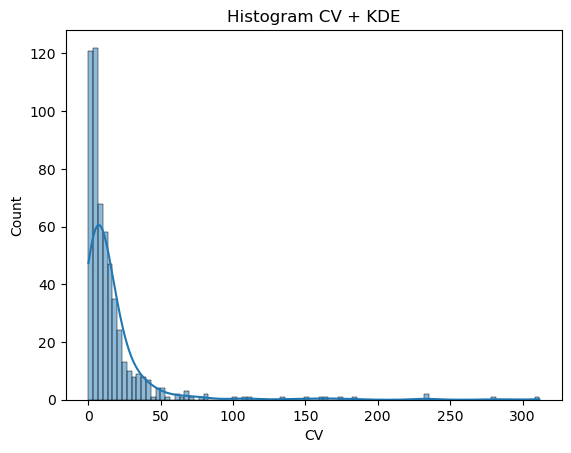

In [3]:
# Normality checks
stat_CV, p_CV = shapiro(ratings["CV"])
print(f"Shapiro-Wilk test CV: W = {stat_CV:.4f}, p = {p_CV:.4f}")

stat_IQR, p_IQR = shapiro(ratings["IQR"])
print(f"Shapiro-Wilk test IQR: W = {stat_IQR:.4f}, p = {p_IQR:.4f}")

stat_var, p_var = shapiro(ratings["ratings_variance"])
print(f"Shapiro-Wilk test variance: W = {stat_var:.4f}, p = {p_var:.4f}")


#homogeneity of variances
groups = ratings["group"].dropna().unique()

group_CV = [ratings[ratings["group"] == g]["CV"].dropna() for g in groups]
group_IQR = [ratings[ratings["group"] == g]["IQR"].dropna() for g in groups]
group_var = [ratings[ratings["group"] == g]["ratings_variance"].dropna() for g in groups]


lev_stat_CV, lev_p_CV = levene(*group_CV)
print(f"Levene’s test for CV across groups: stat = {lev_stat_CV:.4f}, p = {lev_p_CV:.4f}")

lev_stat_IQR, lev_p_IQR = levene(*group_IQR)
print(f"Levene’s test for IQR across groups: stat = {lev_stat_IQR:.4f}, p = {lev_p_IQR:.4f}")

lev_stat_var, lev_p_var = levene(*group_var)
print(f"Levene’s test for variance across groups: stat = {lev_stat_var:.4f}, p = {lev_p_var:.4f}")


# Histograms
sns.histplot(ratings["CV"], kde=True)
plt.title("Histogram CV + KDE")
plt.show()



Text(0.5, 1.0, 'Histogram IQR + KDE')

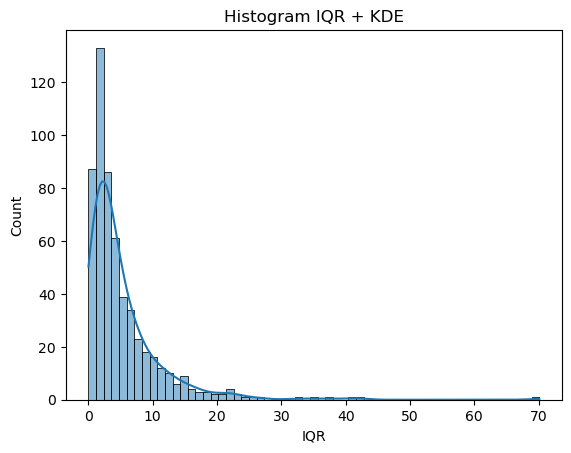

In [4]:
sns.histplot(ratings["IQR"], kde=True)
plt.title("Histogram IQR + KDE")

Text(0.5, 1.0, 'Histogram var + KDE')

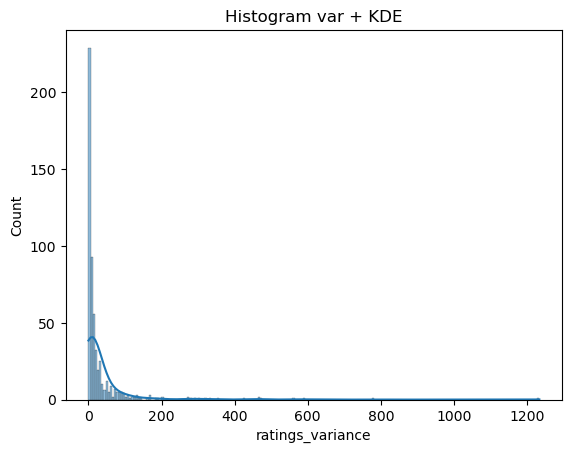

In [5]:
sns.histplot(ratings["ratings_variance"], kde=True)
plt.title("Histogram var + KDE")

### Mixed design non parametric tests - ART ANOVA

#### Since the assumptions of ANOVA are not met, a non-parametric equivalent of the mixed-design ANOVA will be considered

In [3]:
def align_and_rank(df, reduced_formula, dep_variable):
    '''  
    Function that aligns data and ranks dataframe data for ART
    Anova analysis:
    subtracts the fitted model value from the data, to estimate
    the impact of an effect on the dependent variable.

    Params:
    df: dataframe containing the demeaned ratings per subject and visit.
    reduced_formula: formula describing the effects being tested
    dep_variable: the dependent variable of the statistical analysis
    '''
    model_reduced = ols(reduced_formula, data=df).fit()
    aligned = df[dep_variable] - model_reduced.fittedvalues
    ranked = rankdata(aligned)
    return ranked

def ART_anova(df, dep_variable, exclude_chronic= False):
    '''
    Function that performs ART ANOVA
    
    Params: 
    df: dataframe containing the demeaned ratings per subject and visit.
    dep_variable: the dependent variable of the statistical analysis
    exclude_chronic: possibility to exclude the chronic group from the
    analysis. False by default.

    Returns:
    df: dataframe containing columns with ranked and aligned data per effect 
    factor (group, visit, and interaction of group*visit)
    anova_group: anova test for the group factor
    anova_visit: anova test for the visit factor
    anova_interaction: anova test for the interaction factors(group*visit)
    ''' 
    if exclude_chronic == True:
        # Filter to exclude chronic group
        df = df[df['group'] != 'chronic'].copy()

    # Rank aligned for each effect
    df['rank_group'] = align_and_rank(df, f'{dep_variable} ~ visit + group:visit', dep_variable)
    df['rank_visit'] = align_and_rank(df, f'{dep_variable} ~ group + group:visit', dep_variable)
    df['rank_interaction'] = align_and_rank(df, f'{dep_variable} ~ group + visit', dep_variable)

    # Main effect: Group
    model_group = ols('rank_group ~ group', data=df).fit()
    anova_group = anova_lm(model_group, typ=2)
    
    # Main effect: Visit
    model_visit = ols('rank_visit ~ visit + subject', data=df).fit()
    anova_visit = anova_lm(model_visit, typ=2)
    
    # Interaction
    model_interaction = ols('rank_interaction ~ group * visit + subject', data=df).fit()
    anova_interaction = anova_lm(model_interaction, typ=2)

    return df, anova_group, anova_visit, anova_interaction

In [6]:
#CV

df_CV, anova_group_CV, anova_visit_CV, anova_interaction_CV = ART_anova(ratings, "CV")
display(anova_group_CV, anova_visit_CV, anova_interaction_CV)

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/statsmodels/base/model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 94, but rank is 93
  'rank is %d' % (J, J_), ValueWarning)


,sum_sq,df,F,PR(>F)
group,4.035849e+05,2.0,8.046902,0.000359
Residual,1.384253e+07,552.0,NaN,NaN


,sum_sq,df,F,PR(>F)
visit,2.825155e+05,3.0,6.227090,3.750629e-04
subject,7.592139e+06,94.0,5.340727,1.174843e-34
Residual,7.032162e+06,465.0,NaN,NaN


,sum_sq,df,F,PR(>F)
group,2.671485e+05,2.0,10.427121,3.740408e-05
visit,2.690067e+05,3.0,6.999766,1.306203e-04
subject,1.000852e+07,94.0,8.311579,1.627353e-55
group:visit,2.884552e+05,6.0,3.752917,1.175385e-03
Residual,5.790242e+06,452.0,NaN,NaN


In [8]:
#IQR 
df_IQR, anova_group_IQR, anova_visit_IQR, anova_interaction_IQR = ART_anova(ratings, "IQR")
display(anova_group_IQR, anova_visit_IQR, anova_interaction_IQR)

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/statsmodels/base/model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 94, but rank is 93
  'rank is %d' % (J, J_), ValueWarning)


,sum_sq,df,F,PR(>F)
group,1.946425e+04,2.0,0.377611,0.685674
Residual,1.422665e+07,552.0,NaN,NaN


,sum_sq,df,F,PR(>F)
visit,3.402518e+05,3.0,7.067482,1.183317e-04
subject,7.008714e+06,94.0,4.646179,5.699534e-29
Residual,7.462210e+06,465.0,NaN,NaN


,sum_sq,df,F,PR(>F)
group,2.297409e+04,2.0,0.703413,4.954340e-01
visit,3.834609e+05,3.0,7.827123,4.202468e-05
subject,7.142802e+06,94.0,4.653108,1.451721e-28
group:visit,1.761927e+05,6.0,1.798204,9.778090e-02
Residual,7.381355e+06,452.0,NaN,NaN


In [9]:
#Variance
df_var, anova_group_var, anova_visit_var, anova_interaction_var = ART_anova(ratings, "ratings_variance")
display(anova_group_var, anova_visit_var, anova_interaction_var)

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/statsmodels/base/model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 94, but rank is 93
  'rank is %d' % (J, J_), ValueWarning)


,sum_sq,df,F,PR(>F)
group,1.439489e+05,2.0,2.817291,0.060627
Residual,1.410216e+07,552.0,NaN,NaN


,sum_sq,df,F,PR(>F)
visit,1.939803e+06,3.0,43.784136,6.158266e-25
subject,5.949650e+06,94.0,4.285920,6.064717e-26
Residual,6.867086e+06,465.0,NaN,NaN


,sum_sq,df,F,PR(>F)
group,3.086258e+02,2.0,0.011242,9.888215e-01
visit,2.536667e+06,3.0,61.598824,2.094287e-33
subject,5.734534e+06,94.0,4.444271,7.534589e-27
group:visit,1.103797e+05,6.0,1.340195,2.376899e-01
Residual,6.204520e+06,452.0,NaN,NaN


In [9]:
display(ratings["group"].value_counts())

SBPp       265
SBPr       160
chronic    130
Name: group, dtype: int64

### Post hoc tests

### ART-C post hoc test

In [30]:
def artc_true(df, dep, group='group', visit='visit'):
    '''Performs ART-C post hoc tests for ART-Anova'''
    # Step 1: Concatenate group×visit
    df = df.copy()
    df['group_visit'] = df[group].astype(str) + "_" + df[visit].astype(str)

    # Drop originals (per paper Step 1.2)
    # Keep only concatenated factor for contrasts
    # But model will include full factorial structure again in Step 4
    
    # Step 2: Compute aligned Y'
    grand_mean = df[dep].mean()

    # Mean per concatenated level (group×visit)
    mean_gv = df.groupby('group_visit')[dep].transform('mean')

    # Mean per group aggregated over visits
    mean_g = df.groupby(group)[dep].transform('mean')

    # Apply 2-factor alignment formula 
    df['Y_prime'] = df[dep] - mean_gv + mean_g - grand_mean

    # Step 3: Midranks -> Y''
    df['Y_ranked'] = rankdata(df['Y_prime'], method='average')

    # Step 4: Full factorial model with aligned-ranked data
    # Contrast test only on group_visit (concatenated factor)
    model = smf.ols("Y_ranked ~ C(group)*C(visit)", data=df).fit()

    # Compute contrast matrix for group×visit levels
    # Only interpret contrasts among group_visit levels
    contrast = sm.stats.anova_lm(model, typ=2)

    return df, model, contrast

In [31]:
df_c, model_c, anova_c = artc_true(ratings, "CV")
display(anova_c)

,sum_sq,df,F,PR(>F)
C(group),3.383507e+05,2.0,7.789396,4.620911e-04
C(visit),2.527424e+05,3.0,3.879035,9.201892e-03
C(group):C(visit),1.839785e+06,6.0,14.118308,5.736773e-15
Residual,1.179324e+07,543.0,NaN,NaN


In [32]:
def pairwise_mwu(data, group_col, value_col):
    '''
    Function that performs a pairwise Mann-Whitney test
    to establish inter-group and visit differences

    data: dataframe containing the non-demeaned ratings 
    per subject and visit. 
    group_col: column of the dataframe which contains the effect factor
    value_col: column of the dataframe which contains ranked data 
    '''
    results = []
    levels = data[group_col].unique()
    for a, b in combinations(levels, 2):
        group_a = data[data[group_col] == a][value_col]
        group_b = data[data[group_col] == b][value_col]

        # 🛠 Debug print
        print(f'Comparing {a} (n={len(group_a)}) vs {b} (n={len(group_b)})')

        if len(group_a) > 0 and len(group_b) > 0:
            stat, p = mannwhitneyu(group_a, group_b, alternative='two-sided')
            results.append({'group1': a, 'group2': b, 'U': stat, 'p': p})
        else:
            print(f"Skipping comparison: {a} vs {b} — one is empty.")
    return pd.DataFrame(results)

def run_posthoc_mwu(df, effect, ranked_data):
    """
    Function that performs Run Mann-Whitney post-hoc tests on ART-ranked data.

    Params:
    df: dataFrame with your aligned & ranked columns
    effect: 'group', 'visit', or 'interaction'
    ranked_data: the name of the column to use (e.g., 'rank_group', 'rank_visit', 'rank_interaction')

    Returns:
    dataFrame of pairwise post-hoc comparisons
    """

    results = []

    if effect == 'group':
        # Compare groups overall (main effect)
        return pairwise_mwu(df, group_col='group', value_col=ranked_data)

    elif effect == 'visit':
        # Compare visits overall (main effect)
        return pairwise_mwu(df, group_col='visit', value_col=ranked_data)

    elif effect == 'interaction_group_by_visit':
        # Compare groups within each visit (interaction)
        for visit_level in df['visit'].unique():
            subset = df[df['visit'] == visit_level]
            result = pairwise_mwu(subset, group_col='group', value_col=ranked_data)
            result['visit'] = visit_level
            results.append(result)
        return pd.concat(results, ignore_index=True)

    elif effect == 'interaction_visit_by_group':
        # Compare visits within each group (interaction)
        for group_level in df['group'].unique():
            subset = df[df['group'] == group_level]
            result = pairwise_mwu(subset, group_col='visit', value_col=ranked_data)
            result['group'] = group_level
            results.append(result)
        return pd.concat(results, ignore_index=True)

    else:
        raise ValueError("Effect must be 'group', 'visit', 'interaction_group_by_visit', or 'interaction_visit_by_group'")

In [33]:
display(run_posthoc_mwu(df_CV, effect='group', ranked_data='rank_group'))
display(run_posthoc_mwu(df_CV, effect='visit', ranked_data='rank_visit'))
display(run_posthoc_mwu(df_CV, effect='interaction_group_by_visit', ranked_data='rank_interaction'))

NameError: name 'df_CV' is not defined

In [ ]:
display(run_posthoc_mwu(df_IQR, effect='group', ranked_data='rank_group'))
display(run_posthoc_mwu(df_IQR, effect='visit', ranked_data='rank_visit'))
display(run_posthoc_mwu(df_IQR, effect='interaction_group_by_visit', ranked_data='rank_interaction'))

Comparing SBPr (n=160) vs SBPp (n=265)
Comparing SBPr (n=160) vs chronic (n=130)
Comparing SBPr (n=160) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=265) vs chronic (n=130)
Comparing SBPp (n=265) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing chronic (n=130) vs nan (n=0)
Skipping comparison: chronic vs nan — one is empty.


,group1,group2,U,p
0,SBPr,SBPp,23733.0,0.038998
1,SBPr,chronic,9253.0,0.106461
2,SBPp,chronic,15499.0,0.105594


Comparing visit1 (n=159) vs visit2 (n=148)
Comparing visit1 (n=159) vs visit4 (n=107)
Comparing visit1 (n=159) vs visit3 (n=149)
Comparing visit2 (n=148) vs visit4 (n=107)
Comparing visit2 (n=148) vs visit3 (n=149)
Comparing visit4 (n=107) vs visit3 (n=149)


,group1,group2,U,p
0,visit1,visit2,6356.0,3.389695e-12
1,visit1,visit4,5243.0,1.136105e-07
2,visit1,visit3,6125.0,2.416758e-13
3,visit2,visit4,9133.0,3.666142e-02
4,visit2,visit3,9842.0,1.097566e-01
5,visit4,visit3,5814.0,2.230374e-04


Comparing SBPr (n=43) vs SBPp (n=72)
Comparing SBPr (n=43) vs chronic (n=42)
Comparing SBPr (n=43) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=72) vs chronic (n=42)
Comparing SBPp (n=72) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing chronic (n=42) vs nan (n=0)
Skipping comparison: chronic vs nan — one is empty.
Comparing SBPr (n=46) vs SBPp (n=64)
Comparing SBPr (n=46) vs chronic (n=36)
Comparing SBPr (n=46) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=64) vs chronic (n=36)
Comparing SBPp (n=64) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing chronic (n=36) vs nan (n=0)
Skipping comparison: chronic vs nan — one is empty.
Comparing SBPr (n=27) vs SBPp (n=58)
Comparing SBPr (n=27) vs chronic (n=20)
Comparing SBPr (n=27) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=58) vs chronic (n=20)
Comparing SBPp (n=58) vs nan (n=0)
Skipping compa

,group1,group2,U,p,visit
0,SBPr,SBPp,1666.0,0.497010,visit1
1,SBPr,chronic,902.0,0.996493,visit1
2,SBPp,chronic,1365.0,0.389472,visit1
3,SBPr,SBPp,1582.0,0.506978,visit2
4,SBPr,chronic,607.0,0.039370,visit2
5,SBPp,chronic,968.0,0.187596,visit2
6,SBPr,SBPp,775.0,0.943560,visit4
7,SBPr,chronic,147.0,0.008394,visit4
8,SBPp,chronic,464.0,0.186271,visit4
9,SBPr,SBPp,1630.0,0.697700,visit3


In [ ]:
display(run_posthoc_mwu(df_var, effect='group', ranked_data='rank_group'))
display(run_posthoc_mwu(df_var, effect='visit', ranked_data='rank_visit'))
display(run_posthoc_mwu(df_var, effect='interaction_group_by_visit', ranked_data='rank_interaction'))


Comparing SBPr (n=160) vs SBPp (n=265)
Comparing SBPr (n=160) vs chronic (n=130)
Comparing SBPr (n=160) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=265) vs chronic (n=130)
Comparing SBPp (n=265) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing chronic (n=130) vs nan (n=0)
Skipping comparison: chronic vs nan — one is empty.


,group1,group2,U,p
0,SBPr,SBPp,23733.0,0.038998
1,SBPr,chronic,9253.0,0.106461
2,SBPp,chronic,15499.0,0.105594


Comparing visit1 (n=159) vs visit2 (n=148)
Comparing visit1 (n=159) vs visit4 (n=107)
Comparing visit1 (n=159) vs visit3 (n=149)
Comparing visit2 (n=148) vs visit4 (n=107)
Comparing visit2 (n=148) vs visit3 (n=149)
Comparing visit4 (n=107) vs visit3 (n=149)


,group1,group2,U,p
0,visit1,visit2,6356.0,3.389695e-12
1,visit1,visit4,5243.0,1.136105e-07
2,visit1,visit3,6125.0,2.416758e-13
3,visit2,visit4,9133.0,3.666142e-02
4,visit2,visit3,9842.0,1.097566e-01
5,visit4,visit3,5814.0,2.230374e-04


Comparing SBPr (n=43) vs SBPp (n=72)
Comparing SBPr (n=43) vs chronic (n=42)
Comparing SBPr (n=43) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=72) vs chronic (n=42)
Comparing SBPp (n=72) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing chronic (n=42) vs nan (n=0)
Skipping comparison: chronic vs nan — one is empty.
Comparing SBPr (n=46) vs SBPp (n=64)
Comparing SBPr (n=46) vs chronic (n=36)
Comparing SBPr (n=46) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=64) vs chronic (n=36)
Comparing SBPp (n=64) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing chronic (n=36) vs nan (n=0)
Skipping comparison: chronic vs nan — one is empty.
Comparing SBPr (n=27) vs SBPp (n=58)
Comparing SBPr (n=27) vs chronic (n=20)
Comparing SBPr (n=27) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=58) vs chronic (n=20)
Comparing SBPp (n=58) vs nan (n=0)
Skipping compa

,group1,group2,U,p,visit
0,SBPr,SBPp,1666.0,0.497010,visit1
1,SBPr,chronic,902.0,0.996493,visit1
2,SBPp,chronic,1365.0,0.389472,visit1
3,SBPr,SBPp,1582.0,0.506978,visit2
4,SBPr,chronic,607.0,0.039370,visit2
5,SBPp,chronic,968.0,0.187596,visit2
6,SBPr,SBPp,775.0,0.943560,visit4
7,SBPr,chronic,147.0,0.008394,visit4
8,SBPp,chronic,464.0,0.186271,visit4
9,SBPr,SBPp,1630.0,0.697700,visit3


### Permutation test

In [14]:
def permutation_test(data, group_col, value_col, n_permutations=10000, exclude_chronic = False):
    '''
    Function that performs n_permutations iterations to the original 
    dataframe and performs permutation tests between the real and 
    permutated dataset.

    Params:
    data: dataframe containing the non-demeaned ratings 
    per subject and visit. 
    group_col: column of the dataframe which contains the effect factor
    value_col: column of the dataframe which contains ranked data 
    n_permutations: number of permutations of the original dataset used to 
    create an empirical null distribution.
    exclude_chronic: possibility to exclude chronic patients from analysis.
    false by default

    Returns:
    dataframe of permutation test results 
    '''
    results = []

    if exclude_chronic == True:
        data = data[data[group_col] != 'chronic']

    # Remove rows with missing group or CV values
    data = data.dropna(subset=[group_col, value_col])
    
    groups = data[group_col].dropna().unique()

    for a, b in combinations(groups, 2):
        vals_a = data[data[group_col] == a][value_col].values
        vals_b = data[data[group_col] == b][value_col].values

        if len(vals_a) == 0 or len(vals_b) == 0:
            continue

        observed_cv_diff = np.mean(vals_a) - np.mean(vals_b)
        combined = np.concatenate([vals_a, vals_b])
        labels = np.array([a] * len(vals_a) + [b] * len(vals_b))

        perm_diffs = []
        for _ in range(n_permutations):
            np.random.shuffle(labels)
            perm_a = combined[labels == a]
            perm_b = combined[labels == b]

            if len(perm_a) > 1 and len(perm_b) > 1:
                cv_a = np.mean(perm_a)
                cv_b = np.mean(perm_b)
                perm_diffs.append(cv_a - cv_b)

        if len(perm_diffs) == 0:
            p_perm = np.nan
        else:
            p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_cv_diff))

        results.append({
            'group1': a,
            'group2': b,
            'observed_cv_diff': observed_cv_diff,
            'p_permutation': p_perm
        })

    return pd.DataFrame(results)

### Checking significance of CV using bootstrap and permutation method

In [15]:
# CV results using permutation and bootstrap on group and visit, and their interaction

cv_permutation_results_group = permutation_test(ratings, group_col='group', value_col='CV')

cv_permutation_results_visit = permutation_test(ratings, group_col='visit', value_col='CV')


display(cv_permutation_results_group, cv_permutation_results_visit)

,group1,group2,observed_cv_diff,p_permutation
0,SBPr,SBPp,5.654198,0.0817
1,SBPr,chronic,9.136110,0.0111
2,SBPp,chronic,3.481911,0.2230


,group1,group2,observed_cv_diff,p_permutation
0,visit1,visit2,4.492109,0.2010
1,visit1,visit4,0.623873,0.8834
2,visit1,visit3,2.598659,0.5151
3,visit2,visit4,-3.868236,0.2193
4,visit2,visit3,-1.893450,0.5638
5,visit4,visit3,1.974786,0.6212


### Checking significance of IQR with bootstrap and permutation method
### !!! this is for explorative purposes since IQR is not significant - please skip if not needed

In [16]:
# IQR results using permutation and bootstrap on group and visit, and their interaction

iqr_permutation_results_group = permutation_test(ratings, group_col='group', value_col='IQR')

iqr_permutation_results_visit = permutation_test(ratings, group_col='visit', value_col='IQR')

display(iqr_permutation_results_group, iqr_permutation_results_visit)

,group1,group2,observed_cv_diff,p_permutation
0,SBPr,SBPp,-0.541230,0.3613
1,SBPr,chronic,0.323579,0.7099
2,SBPp,chronic,0.864809,0.1947


,group1,group2,observed_cv_diff,p_permutation
0,visit1,visit2,2.770645,0.0003
1,visit1,visit4,2.321087,0.0115
2,visit1,visit3,2.554164,0.0010
3,visit2,visit4,-0.449558,0.4699
4,visit2,visit3,-0.216481,0.6901
5,visit4,visit3,0.233077,0.6908


### Checking significance of variance with bootstrap and permutation method

In [17]:

var_permutation_results_group = permutation_test(ratings, group_col='group', value_col='ratings_variance')

var_permutation_results_visit = permutation_test(ratings, group_col='visit', value_col='ratings_variance')

display(var_permutation_results_group, var_permutation_results_visit)

,group1,group2,observed_cv_diff,p_permutation
0,SBPr,SBPp,-4.021377,0.6259
1,SBPr,chronic,1.231260,0.9287
2,SBPp,chronic,5.252637,0.6168


,group1,group2,observed_cv_diff,p_permutation
0,visit1,visit2,32.427318,0.0045
1,visit1,visit4,24.652909,0.0950
2,visit1,visit3,34.860762,0.0009
3,visit2,visit4,-7.774409,0.3366
4,visit2,visit3,2.433444,0.6947
5,visit4,visit3,10.207852,0.1482


### Analysis without chronic group: 
#### Since the results suggest that the chronic group leads variance, excluding it from the analysis allows to study what part of the variance is brought about by the persistent and recovering group (SBPp and SBPr, respectively)

In [7]:
#CV
df_CV_nc, anova_group_CV_nc, anova_visit_CV_nc, anova_interaction_CV_nc = ART_anova(ratings, "CV", exclude_chronic=True)
display(anova_group_CV_nc, anova_visit_CV_nc, anova_interaction_CV_nc)

#IQR
df_IQR_nc, anova_group_IQR_nc, anova_visit_IQR_nc, anova_interaction_IQR_nc = ART_anova(ratings, "IQR", exclude_chronic = True)
#display(anova_group_IQR_nc, anova_visit_IQR_nc, anova_interaction_IQR_nc)

#var
df_var_nc, anova_group_var_nc, anova_visit_var_nc, anova_interaction_var_nc = ART_anova(ratings, "ratings_variance", 
                                                                                        exclude_chronic = True)
#display(anova_group_var_nc, anova_visit_var_nc, anova_interaction_var_nc)

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/statsmodels/base/model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 70, but rank is 69
  'rank is %d' % (J, J_), ValueWarning)


,sum_sq,df,F,PR(>F)
group,9.490259e+04,1.0,6.369809,0.011973
Residual,6.302197e+06,423.0,NaN,NaN


,sum_sq,df,F,PR(>F)
visit,1.229376e+05,3.0,4.463571,4.292532e-03
subject,3.347059e+06,70.0,5.208161,7.119778e-26
Residual,3.295910e+06,359.0,NaN,NaN


,sum_sq,df,F,PR(>F)
group,3.630161e+03,1.0,0.475086,4.911144e-01
visit,1.565447e+05,3.0,6.829107,1.749322e-04
subject,4.404212e+06,70.0,8.234114,4.110020e-42
group:visit,1.334691e+05,3.0,5.822454,6.841524e-04
Residual,2.666728e+06,349.0,NaN,NaN


/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/statsmodels/base/model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 70, but rank is 69
  'rank is %d' % (J, J_), ValueWarning)
/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/statsmodels/base/model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 70, but rank is 69
  'rank is %d' % (J, J_), ValueWarning)


### Post hoc without chronic

In [10]:
display(run_posthoc_mwu(df_CV_nc, effect='interaction_group_by_visit', ranked_data='rank_interaction'))

Comparing SBPr (n=43) vs SBPp (n=72)
Comparing SBPr (n=43) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=72) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing SBPr (n=46) vs SBPp (n=64)
Comparing SBPr (n=46) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=64) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing SBPr (n=27) vs SBPp (n=58)
Comparing SBPr (n=27) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=58) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.
Comparing SBPr (n=44) vs SBPp (n=71)
Comparing SBPr (n=44) vs nan (n=0)
Skipping comparison: SBPr vs nan — one is empty.
Comparing SBPp (n=71) vs nan (n=0)
Skipping comparison: SBPp vs nan — one is empty.


,group1,group2,U,p,visit
0,SBPr,SBPp,953.0,0.000589,visit1
1,SBPr,SBPp,842.0,0.000136,visit2
2,SBPr,SBPp,773.0,0.928546,visit4
3,SBPr,SBPp,1438.0,0.477284,visit3


In [19]:
# CV results using permutation and bootstrap on group and visit, and their interaction


CV_permutation_results_group_nc = permutation_test(ratings, group_col='group', value_col='CV', exclude_chronic=True)

CV_permutation_results_visit_nc = permutation_test(ratings, group_col='visit', value_col='CV', exclude_chronic = True)

display(CV_permutation_results_group_nc, CV_permutation_results_visit_nc)

,group1,group2,observed_cv_diff,p_permutation
0,SBPr,SBPp,5.654198,0.08


,group1,group2,observed_cv_diff,p_permutation
0,visit1,visit2,4.492109,0.2070
1,visit1,visit4,0.623873,0.8828
2,visit1,visit3,2.598659,0.5167
3,visit2,visit4,-3.868236,0.2122
4,visit2,visit3,-1.893450,0.5551
5,visit4,visit3,1.974786,0.6159


In [20]:
# IQR results using permutation and bootstrap on group and visit, and their interaction

IQR_permutation_results_group_nc = permutation_test(ratings, group_col='group', value_col='IQR', exclude_chronic = True)
IQR_permutation_results_visit_nc = permutation_test(ratings, group_col='visit', value_col='IQR', exclude_chronic = True)

display(IQR_permutation_results_group_nc , IQR_permutation_results_visit_nc)

,group1,group2,observed_cv_diff,p_permutation
0,SBPr,SBPp,-0.54123,0.3657


,group1,group2,observed_cv_diff,p_permutation
0,visit1,visit2,2.770645,0.0003
1,visit1,visit4,2.321087,0.0096
2,visit1,visit3,2.554164,0.0012
3,visit2,visit4,-0.449558,0.4698
4,visit2,visit3,-0.216481,0.6956
5,visit4,visit3,0.233077,0.6941


In [21]:
# variance results using permutation and bootstrap on group and visit, and their interaction

var_permutation_results_group_nc = permutation_test(ratings, group_col='group', value_col='ratings_variance', exclude_chronic=True)
var_permutation_results_visit_nc = permutation_test(ratings, group_col='visit', value_col='ratings_variance', exclude_chronic=True)

display(var_permutation_results_group_nc, var_permutation_results_visit_nc)

,group1,group2,observed_cv_diff,p_permutation
0,SBPr,SBPp,-4.021377,0.6214


,group1,group2,observed_cv_diff,p_permutation
0,visit1,visit2,32.427318,0.0038
1,visit1,visit4,24.652909,0.0942
2,visit1,visit3,34.860762,0.0018
3,visit2,visit4,-7.774409,0.3370
4,visit2,visit3,2.433444,0.7020
5,visit4,visit3,10.207852,0.1471
